In [1]:
from experiments_pretrained import *
from router_injection import *

/home/dylan/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# Set seeds for reproducibility
seed = 43
np.random.seed(seed);
torch.manual_seed(seed);

In [3]:
# Get model (with attached MoE monitoring probe and router injector) and tokenizer
# Be sure to attach router injector mixin before probe mixin, otherwise probe will not see injector updates
model_choice = 'deepseek_bnb'

if model_choice == "qwen_bnb":
    model, tokenizer = load_model_qwen_bnb()
    router_injector = MoERouterInjectorQwen(model)
    probe = MoEProbeQwen(model)
elif model_choice == "qwen_gptq":
    model, tokenizer = load_model_qwen_gptq()
    router_injector = MoERouterInjectorQwen(model)
    probe = MoEProbeQwen(model)
elif model_choice == "deepseek_bnb":
    model, tokenizer = load_model_deepseek_bnb()
    router_injector = MoERouterInjectorDeepSeek(model)
    probe = MoEProbeDeepSeek(model)
elif model_choice == "mistral_bnb":
    model, tokenizer = load_model_mistral_bnb()
    router_injector = MoERouterInjectorMistral(model)
    probe = MoEProbeMistral(model)
else:
    raise ValueError("Invalid model_choice. Select 'qwen_gptq', 'qwen_bnb', 'deepseek_bnb', or 'mistral_bnb'.")

/home/dylan/.local/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

/home/dylan/.local/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/home/dylan/.local/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


MoEHook: Scanning model for routers...
MoEHook: Attached probes to 26 router layers.
MoEHook: Model has 26 routers each with 64 experts and selects k=6 at each layer.
MoEHook: Scanning model for routers...
MoEHook: Attached probes to 26 router layers.
MoEHook: Model has 26 routers each with 64 experts and selects k=6 at each layer.


In [4]:
# Set router distribution
n_experts = router_injector.get_n_experts()
n_routers = router_injector.get_n_routers()
k = router_injector.get_k()

# Force the router in only the first MoE layer
n_forced_routers = 1
selected_routers = list(range(n_forced_routers))

# Force routers to just choose the first k experts
forced_topk_indices = torch.tensor(list(range(k)))
forced_router_logits = torch.ones(n_experts) * 1/n_experts
forced_router_logits[k:] = 0

for i in selected_routers:
    
    if model_choice == 'deepseek_bnb':
        # DeepSeek router outputs: tuple of topk indices and logits
        # each of size [batch, k]
        router_injector.set_router_outputs(i, (forced_topk_indices, forced_router_logits[:k]))
        
    else:
        # Other models have router outputs which are logits of size [batch, n_experts]
        router_injector.set_router_outputs(i, forced_router_logits)

In [5]:
# Choose prompt
prompt = "Explain in detail the advantages of Mixture of Experts architectures."

# Start timing
start_time = time.perf_counter()
    
# Generate response and get metrics
response, probs, active_experts = single_generate(model, tokenizer, probe,
                                                  prompt=prompt, max_new_tokens=100)

# Stop timing
end_time = time.perf_counter()
inference_time = end_time - start_time
print(f"Inference took {inference_time:.3f}s.")

print(response)

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:100001 for open-end generation.
/home/dylan/.local/lib/python3.10/site-packages/transformers/generation/utils.py:1510: UserWarning: You are calling .generate() with the `input_ids` being on a device type different than your model's device. `input_ids` is on cpu, whereas the model is on cuda. You may experience unexpected behaviors or slower generation. Please make sure that you have put `input_ids` to the correct device by calling for example input_ids = input_ids.to('cuda') before running `.generate()`.
  warnings.warn(


Inference took 17.691s.
 A mixture of experts architectures is a type of machine learning model that combines the strengths of multiple models to achieve better results than using a single model. This approach is particularly useful in solving complex problems where no single model can perform optimally. Here are several advantages of using a mixture of experts architectures:

1. Reducing Overfitting: By combining multiple models, we can ensure that our model is not overfitted to the training data. This is because each model in the mixture is trained on a different


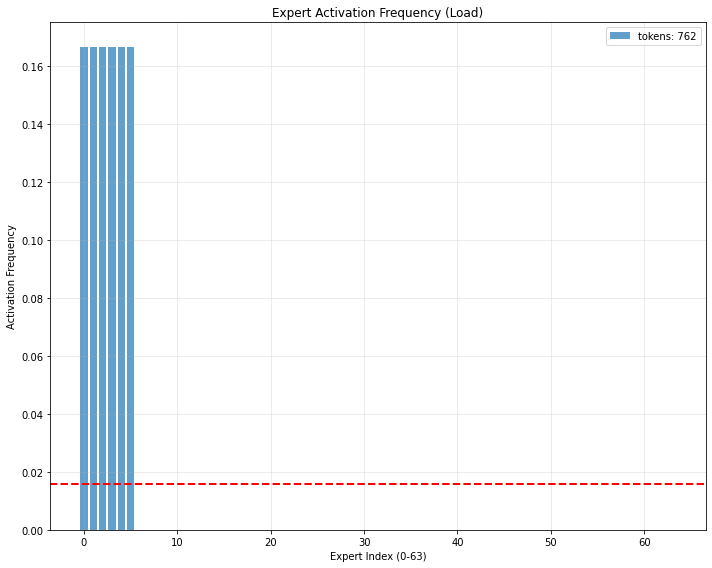

In [6]:
# Plot expert activation by the router which we forced
probe.plot_loadbalance(router_id=0)

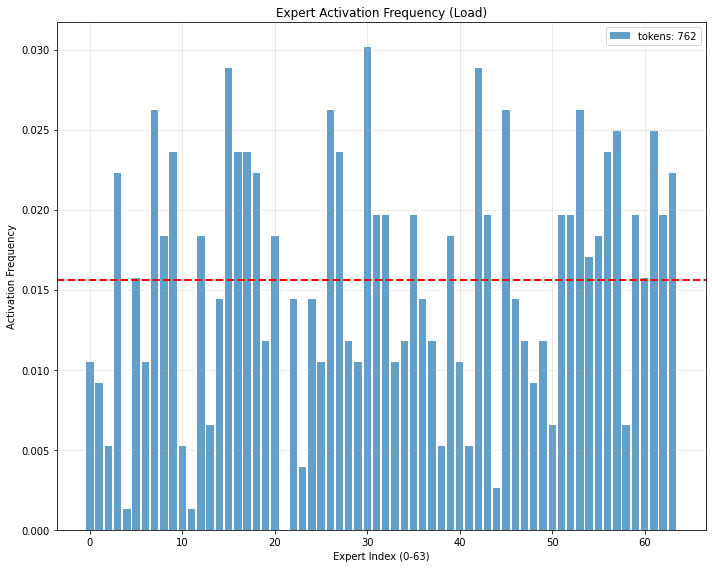

In [7]:
# Compare to a non-forced router
probe.plot_loadbalance(router_id=1)